In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/gym_fitness_clustering.csv")

In [49]:
df

,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,BMI,Cluster_Intitial,Cluster_Optimal
0,157,60,1.69,1313.0,12.6,30.20,0,4
1,151,66,1.30,883.0,33.9,32.00,1,1
2,122,54,1.11,677.0,33.4,24.71,1,0
3,164,56,0.59,532.0,28.8,18.41,1,0
4,158,68,0.64,556.0,29.2,14.39,1,2
...,...,...,...,...,...,...,...,...
968,158,67,1.57,1364.0,10.0,28.77,0,4
969,166,56,1.38,1260.0,25.0,25.69,0,3
970,120,53,1.72,929.0,18.8,19.50,0,4
971,146,62,1.10,883.0,28.2,37.74,1,1


In [4]:
df.isna().sum()

Avg_BPM                      0
Resting_BPM                  0
Session_Duration (hours)     0
Calories_Burned             35
Fat_Percentage              28
BMI                          0
dtype: int64

In [5]:
print(df['Calories_Burned'].skew())

0.2772383150912852


In [6]:
print(df['Fat_Percentage'].skew())

-0.6314734543596465


In [7]:
df['Calories_Burned'] = df['Calories_Burned'].fillna(df['Calories_Burned'].mean()) 
df['Fat_Percentage'] = df['Fat_Percentage'].fillna(df['Fat_Percentage'].mean()) 

In [8]:
df.isna().sum()

Avg_BPM                     0
Resting_BPM                 0
Session_Duration (hours)    0
Calories_Burned             0
Fat_Percentage              0
BMI                         0
dtype: int64

In [9]:
df.columns

Index(['Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Fat_Percentage', 'BMI'],
      dtype='str')

In [10]:
features = ['Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Fat_Percentage', 'BMI']
x = df[features].copy()
x.head()

,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,BMI
0,157,60,1.69,1313.0,12.6,30.20
1,151,66,1.30,883.0,33.9,32.00
2,122,54,1.11,677.0,33.4,24.71
3,164,56,0.59,532.0,28.8,18.41
4,158,68,0.64,556.0,29.2,14.39


In [11]:
scale = StandardScaler()
x_scaled = scale.fit_transform(x)
x_scaled

array([[ 0.92297044, -0.30355488,  1.26459826,  1.52462461, -1.99690114,
         0.7942783 ],
       [ 0.50449409,  0.51574859,  0.12709832, -0.07995027,  1.44789965,
         1.06465186],
       [-1.51814158, -1.12285836, -0.42706833, -0.84865358,  1.36703578,
        -0.03036106],
       ...,
       [-1.65763369, -1.25940893,  1.35209826,  0.09170193, -0.99418917,
        -0.81294232],
       [ 0.15576381, -0.03045373, -0.45623499, -0.07995027,  0.52605155,
         1.92684311],
       [ 0.15576381,  0.51574859, -1.47706828, -1.35241547,  0.62308819,
         1.27193826]], shape=(973, 6))

In [12]:
initial_k = 2 
kmeans_init = KMeans(n_clusters = initial_k, random_state = 42, n_init = 10)
labels_init = kmeans_init.fit_predict(x_scaled)
df['Cluster_Intitial'] = labels_init 
df.head()


,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,BMI,Cluster_Intitial
0,157,60,1.69,1313.0,12.6,30.20,0
1,151,66,1.30,883.0,33.9,32.00,1
2,122,54,1.11,677.0,33.4,24.71,1
3,164,56,0.59,532.0,28.8,18.41,1
4,158,68,0.64,556.0,29.2,14.39,1


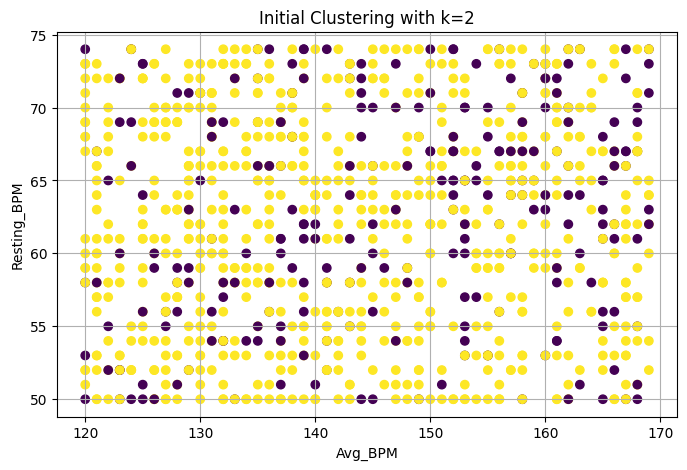

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize= (8,5)) 
plt.scatter(df['Avg_BPM'], df['Resting_BPM'], c = df['Cluster_Intitial'])
plt.xlabel('Avg_BPM')
plt.ylabel('Resting_BPM')
plt.title('Initial Clustering with k=2')
plt.grid(True)
plt.show()


In [18]:
wcs = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k , random_state = 42, n_init = 10)
    kmeans.fit(x_scaled)
    wcs.append(kmeans.inertia_)

In [20]:
wcs

[5838.000000000001,
 4271.397021166511,
 3599.2090497078,
 3166.055093235997,
 2841.0910645483054,
 2570.6858799314195,
 2387.4210684028976,
 2218.8355128460626,
 2114.4556231514925,
 2029.856633059047]

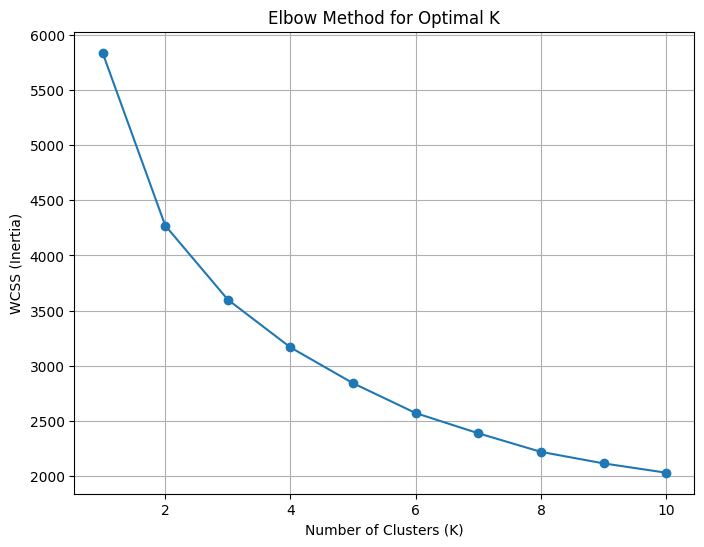

In [21]:
plt.figure(figsize = (8,6))
plt.plot(range(1,11), wcs, marker = 'o') 
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)") 
plt.title("Elbow Method for Optimal K") 
plt.grid(True)
plt.show()

In [39]:
optimal_k = 5
kmeans_opt = KMeans(n_clusters = optimal_k, random_state = 42, n_init = 20)
labels_opt = kmeans_opt.fit_predict(x_scaled)
df['Cluster_Optimal'] = labels_opt 
df.head()


,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,BMI,Cluster_Intitial,Cluster_Optimal
0,157,60,1.69,1313.0,12.6,30.20,0,4
1,151,66,1.30,883.0,33.9,32.00,1,1
2,122,54,1.11,677.0,33.4,24.71,1,0
3,164,56,0.59,532.0,28.8,18.41,1,0
4,158,68,0.64,556.0,29.2,14.39,1,2


In [44]:
score = silhouette_score(x_scaled, df['Cluster_Optimal'])
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2060


In [45]:
silhoutte_scores = []
for k in range(2,10):
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    silhoutte_scores.append(score)


In [46]:
silhoutte_scores

[0.2780531652344839,
 0.2093414080951889,
 0.20457100338710674,
 0.20298475658060042,
 0.20916307479181667,
 0.1980323462721911,
 0.19242217573694856,
 0.19210692126403872]

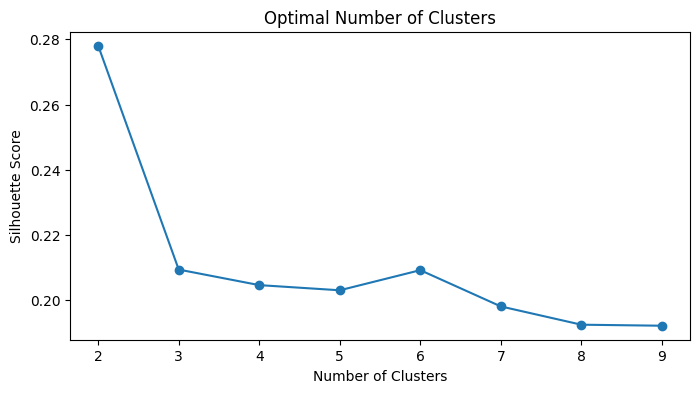

In [47]:
plt.figure(figsize = (8,4))
plt.plot(range(2,10), silhoutte_scores, marker = 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Optimal Number of Clusters')
plt.show()